<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day37_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [34]:
url = "https://raw.githubusercontent.com/njtierney/melb-housing-data/master/data/housing.csv"
df = pd.read_csv(url)

print(f"Dataset: {df.shape[0]:,} properties, {df.shape[1]} features")
df.head()

Dataset: 34,857 properties, 21 features


,suburb,rooms,type,price,method,seller_g,date,distance,postcode,bedroom2,...,car,landsize,building_area,year_built,council_area,latitude,longitude,region_name,property_count,yr_qtr
0,Abbotsford,2,h,NaN,SS,Jellis,2016-09-03,2.5,3067.0,2.0,...,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,2016.3
1,Abbotsford,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,2.0,...,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0,2016.4
2,Abbotsford,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,2.0,...,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0,2016.1
3,Abbotsford,3,u,NaN,VB,Rounds,2016-02-04,2.5,3067.0,3.0,...,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0,2016.1
4,Abbotsford,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,3.0,...,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0,2017.1


In [35]:
# Check columns and types
print("Columns and types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Columns and types:
suburb             object
rooms               int64
type               object
price             float64
method             object
seller_g           object
date               object
distance          float64
postcode          float64
bedroom2          float64
bathroom          float64
car               float64
landsize          float64
building_area     float64
year_built        float64
council_area       object
latitude          float64
longitude         float64
region_name        object
property_count    float64
yr_qtr            float64
dtype: object

Missing values:
price              7610
distance              1
postcode              1
bedroom2           8217
bathroom           8226
car                8728
landsize          11810
building_area     21115
year_built        19306
council_area          3
latitude           7976
longitude          7976
region_name           3
property_count        3
dtype: int64


After dropping missing targets: 27,247 rows


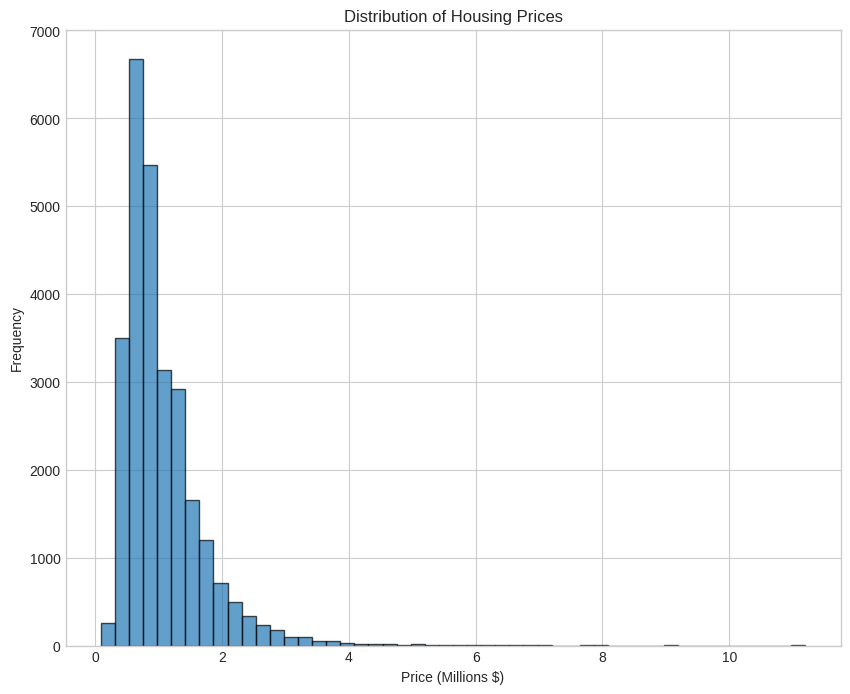

Price Range: $85,000 - $11,200,000


In [36]:
target_col = 'price'
df = df.dropna(subset=[target_col])
print(f"After dropping missing targets: {len(df):,} rows")

plt.figure(figsize=(10, 8))
plt.hist(df[target_col]/1e6, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Price (Millions $)')
plt.ylabel('Frequency')
plt.title('Distribution of Housing Prices')
plt.show()

print(f"Price Range: ${df[target_col].min():,.0f} - ${df[target_col].max():,.0f}")

In [37]:
numeric_features = ['rooms', 'distance', 'bedroom2', 'bathroom', 'car',
                    'landsize', 'building_area', 'year_built', 'latitude', 'longitude'] # Corrected 'buildingArea' to 'building_area' and 'lattitude', 'longtitude' to 'latitude', 'longitude'
categorical_features = ['type', 'method', 'region_name'] # Corrected 'regionname' to 'region_name'
date_features = ['date']

#Filter to available columns
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]
date_features = [c for c in date_features if c in df.columns]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Date features ({len(date_features)}): {date_features}")

Numeric features (10): ['rooms', 'distance', 'bedroom2', 'bathroom', 'car', 'landsize', 'building_area', 'year_built', 'latitude', 'longitude']
Categorical features (3): ['type', 'method', 'region_name']
Date features (1): ['date']


In [38]:
feature_cols = numeric_features + categorical_features + date_features
x = df[feature_cols].copy()
y = df[target_col].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training set: {len(x_train):,} rows")
print(f"Test set: {len(x_test):,} rows")
print(x_train.isnull().sum()[x_train.isnull().sum() > 0])

Training set: 21,797 rows
Test set: 5,450 rows
distance             1
bedroom2          5164
bathroom          5170
car               5473
landsize          7444
building_area    13262
year_built       12120
latitude          5001
longitude         5001
region_name          3
dtype: int64


Basic Pipeline

In [39]:
simple_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.1))
])

simple_pipeline.fit(x_train[numeric_features], y_train)
y_pred_simple = simple_pipeline.predict(x_test[numeric_features])

rmse = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2 = r2_score(y_test, y_pred_simple)

print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

RMSE: 490335.73
R2: 0.44


In [40]:
from sklearn import set_config
set_config(display='diagram')
simple_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', Ridge(alpha=0.1))])

ColumnTransformer (mixed data types)

In [41]:
#numeric pipeline: impute with median, then scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#Categorical pipeline: impute with mode, then one-hot
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#Combine with column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Column Transformer created!!!")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Column Transformer created!!!
Numeric features: ['rooms', 'distance', 'bedroom2', 'bathroom', 'car', 'landsize', 'building_area', 'year_built', 'latitude', 'longitude']
Categorical features: ['type', 'method', 'region_name']


In [42]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

full_pipeline.fit(x_train, y_train)

y_pred_full = full_pipeline.predict(x_test)

rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))
r2_full = r2_score(y_test, y_pred_full)

print("Full pipeline:")
print(f"RMSE: {rmse_full:.2f}")
print(f"R2: {r2_full:.2f}")

Full pipeline:
RMSE: 440568.74
R2: 0.55


In [43]:
full_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['rooms', 'distance',
                                                   'bedroom2', 'bathroom',
                                                   'car', 'landsize',
                                                   'building_area',
                                                   'year_built', 'latitude',
                                                   'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['type', 'method',
                                                   'region_name'])])),
                ('model', Ridge())])

Custom Transformer

In [44]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
  def __init__(self, date_col='Date'):
    self.date_col = date_col

  def fit(self, x, y=None):
    return self

  def transform(self, x):
    x = x.copy()
    if self.date_col in x.columns:
      dates = pd.to_datetime(x[self.date_col], errors='coerce')
      x['Sale_Year'] = dates.dt.year
      x['Sale_Month'] = dates.dt.month
      x['Sale_DateOfWeek'] = dates.dt.dayofweek
      x = x.drop(columns=[self.date_col])
    return x

date_extractor = DateFeatureExtractor('date')
x_train_dates = date_extractor.fit_transform(x_train)

print('After Date Feature Extraction:')
print(x_train_dates[['Sale_Year', 'Sale_Month', 'Sale_DateOfWeek']].head(10))

After Date Feature Extraction:
       Sale_Year  Sale_Month  Sale_DateOfWeek
23012       2017           8                5
8726        2016          12                5
2349        2016          11                0
25277       2017          10                5
21890       2017           8                5
24714       2017          10                5
28373       2017          11                5
19087       2017           7                5
27776       2017          11                5
1873        2016           6                5


In [45]:
#%%
# Another custom transformer: Domain features

class HousingFeatureEngineer(BaseEstimator, TransformerMixin):
    """Create domain-specific features for housing data."""

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()

        # Rooms per bathroom
        if 'rooms' in x.columns and 'bathroom' in x.columns:
            x['Rooms_Per_Bathroom'] = x['rooms'] / (x['bathroom'] + 1)

        # Building to land ratio
        if 'building_area' in x.columns and 'landsize' in x.columns:
            x['Building_Land_Ratio'] = x['building_area'] / (x['landsize'] + 1)

        # Property age
        if 'year_built' in x.columns:
            x['Property_Age'] = 2024 - x['year_built']

        return x


fe = HousingFeatureEngineer()
x_train_fe = fe.fit_transform(x_train)

print("After HousingFeatureEngineer:")
new_cols = ['Rooms_Per_Bathroom', 'Building_Land_Ratio', 'Property_Age']
new_cols = [c for c in new_cols if c in x_train_fe.columns]
print(x_train_fe[new_cols].head())

After HousingFeatureEngineer:
       Rooms_Per_Bathroom  Building_Land_Ratio  Property_Age
23012                 1.0                  NaN          54.0
8726                  NaN                  NaN           NaN
2349                  1.0                 85.0          54.0
25277                 NaN                  NaN           NaN
21890                 1.0                  NaN           NaN


Advanced Pipeline with Custom Transformers

In [46]:
#update feature lists after date extraction
numeric_features_extended = numeric_features + ['Sale_Year', 'Sale_Month', 'Sale_DateOfWeek', 'Rooms_Per_Bathroom', 'Building_Land_Ratio', 'Property_Age']

numeric_features_extended = list(set(numeric_features_extended))

prerocessor_advance = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_extended),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

advanced_pipeline = Pipeline([
    ('date_features', DateFeatureExtractor('date')),
    ('domain_features', HousingFeatureEngineer()),
    ('preprocessor', prerocessor_advance),
    ('model', Ridge(alpha=1.0))
])

In [47]:
advanced_pipeline.fit(x_train, y_train)
y_pred_adv = advanced_pipeline.predict(x_test)

rmse_adv = np.sqrt(mean_squared_error(y_test, y_pred_adv))
r2_adv = r2_score(y_test, y_pred_adv)

print("Advanced pipeline:")
print(f"RMSE: {rmse_adv:.2f}")
print(f"R2: {r2_adv:.2f}")

Advanced pipeline:
RMSE: 437919.20
R2: 0.55


In [50]:
advanced_pipeline

Pipeline(steps=[('date_features', DateFeatureExtractor(date_col='date')),
                ('domain_features', HousingFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude',
                                                   'Sale_DateOfWeek',
                                                   'Property_Age', 'bedroom2',
                                                   'car', 'rooms', 'year_built',
                                                   'Sale_Month', 'longitude',
                                                   'building_area', 'Sale_Year',
                                                   'bathroom',
                                                   'Building_Land_Ratio',
                                                   'distance', 'landsize',
                                                   'Rooms_Per_Bathroom']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['type', 'method',
                                                   'region_name'])])),
                ('model', Ridge())])

Pipeline + GridSearchCV

In [49]:
gs_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'model__alpha': [0.1, 1.0, 10.0, 100.0]
}

print('Parameter grid:')
for param, values in param_grid.items():
  print(f"{param}: {values}")

Parameter grid:
preprocessor__num__imputer__strategy: ['mean', 'median']
model__alpha: [0.1, 1.0, 10.0, 100.0]


In [52]:
grid_search = GridSearchCV(
    gs_pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print('Fitting grid search...')
grid_search.fit(x_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Fitting grid search...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__alpha': 10.0, 'preprocessor__num__imputer__strategy': 'median'}
Best score: -540812.3482576475


In [53]:
#Evaluate the best model
y_pred_gs = grid_search.predict(x_test)
rmse_gs = np.sqrt(mean_squared_error(y_test, y_pred_gs))
r2_gs = r2_score(y_test, y_pred_gs)

print("Grid Search pipeline:")
print(f"RMSE: {rmse_gs:.2f}")
print(f"R2: {r2_gs:.2f}")

Grid Search pipeline:
RMSE: 440651.62
R2: 0.55


Swapping models in Pipeline

In [55]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

model_results = []

for name, model in models.items():
  pipe = Pipeline([
      ('preprocesser', preprocessor),
      ('model', model)
  ])
  pipe.fit(x_train, y_train)
  y_pred = pipe.predict(x_test)

  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)

  model_results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
  print(f"{name:<20} RMSE: {rmse:.2f}, R2: {r2:.2f}")
results_df = pd.DataFrame(model_results).sort_values('R2', ascending=False)
print(f"Best Model: {results_df.iloc[0]['Model']}")

Ridge                RMSE: 440568.74, R2: 0.55
Lasso                RMSE: 440559.93, R2: 0.55
RandomForest         RMSE: 317268.00, R2: 0.76
Gradient Boosting    RMSE: 321206.30, R2: 0.76
Best Model: RandomForest


Saving and loading Pipelines

In [56]:
import joblib

best_pipeline = Pipeline([
    ('preprocessoe', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

best_pipeline.fit(x_train, y_train)

joblib.dump(best_pipeline, 'melbourne_housing_pipeline.joblib')
print("Pipeline saved")

loaded_pipeline = joblib.load('melbourne_housing_pipeline.joblib')
print("Pipeline Loaded")

y_pred_loaded = loaded_pipeline.predict(x_test)
print(f"Predictions match: {np.allclose(y_pred_loaded, best_pipeline.predict(x_test))}")

Pipeline saved
Pipeline Loaded
Predictions match: True


In [61]:
#Simulate Preduction
new_house = x_test.iloc[[0]].copy()

print("New House Features:")
print(new_house.T)

predicted_price = loaded_pipeline.predict(new_house)[0]
actual_price = y_test.iloc[0]
print(f"\nPredicted Price: ${predicted_price:,.2f}")
print(f"Actual Price: ${actual_price:,.2f}")

New House Features:
                               31223
rooms                              2
distance                         3.4
bedroom2                         2.0
bathroom                         1.0
car                              NaN
landsize                       110.0
building_area                   79.0
year_built                    1910.0
latitude                   -37.79372
longitude                  144.92846
type                               h
method                            PI
region_name    Northern Metropolitan
date                      2018-02-10

Predicted Price: $946,551.58
Actual Price: $855,000.00


In [63]:
# Fit preprocessor separately to get feature names
preprocessor.fit(x_train)

# Get feature names
try:
    feature_names_out = preprocessor.get_feature_names_out()
    print(f"Total features after preprocessing: {len(feature_names_out)}")
    print(f"\nFirst 10 features:")
    for f in feature_names_out[:10]:
        print(f"  {f}")
    print("...")
except:
    print("Feature names not available (older sklearn version)")

Total features after preprocessing: 26

First 10 features:
  num__rooms
  num__distance
  num__bedroom2
  num__bathroom
  num__car
  num__landsize
  num__building_area
  num__year_built
  num__latitude
  num__longitude
...


Pipeline Comparison Summary

In [68]:
summary = [
    {'pipeline': 'Simple (numeric only)', 'RMSE':rmse, 'R2': r2},
    {'pipeline': 'Full (numeric + categorical)', 'RMSE':rmse_full, 'R2': r2_full},
    {'pipeline': 'Date Feature Extraction', 'RMSE':rmse_full, 'R2': r2_full},
    {'pipeline': 'Domain Features', 'RMSE':rmse_full, 'R2': r2_full},
    {'pipeline': 'Advanced (numeric + categorical + date)', 'RMSE':rmse_adv, 'R2': r2_adv},
    {'pipeline': 'Grid Search', 'RMSE':rmse_gs, 'R2': r2_gs},
]

summary_df = pd.DataFrame(summary)

print("Pipeline Comparison Summary:")
print(summary_df.to_string(index=False))

Pipeline Comparison Summary:
                               pipeline          RMSE       R2
                  Simple (numeric only) 321206.295294 0.758551
           Full (numeric + categorical) 440568.742422 0.545761
                Date Feature Extraction 440568.742422 0.545761
                        Domain Features 440568.742422 0.545761
Advanced (numeric + categorical + date) 437919.195570 0.551208
                            Grid Search 440651.623628 0.545590


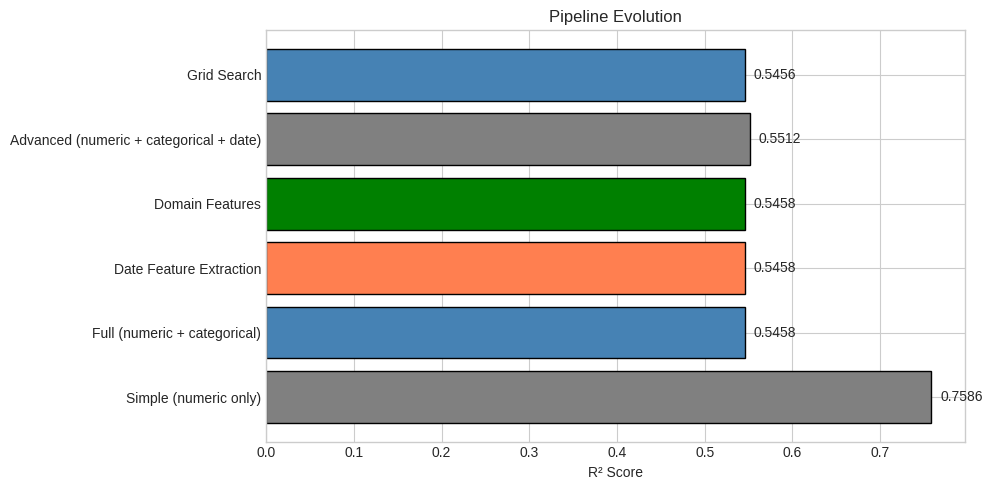

In [70]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['gray', 'steelblue', 'coral', 'green']
ax.barh(summary_df['pipeline'], summary_df['R2'], color=colors, edgecolor='black')
ax.set_xlabel('R² Score')
ax.set_title('Pipeline Evolution')

for i, (pipe, r2_val) in enumerate(zip(summary_df['pipeline'], summary_df['R2'])):
    ax.text(r2_val + 0.01, i, f'{r2_val:.4f}', va='center')

plt.tight_layout()
plt.show()


## Summary

### Pipeline Components

| Component | Purpose |
|-----------|--------|
| Pipeline | Chain steps sequentially |
| ColumnTransformer | Different transforms per column |
| Custom Transformer | Your own preprocessing logic |
| make_pipeline | Quick pipeline without names |

### Key Benefits

1. **No data leakage** — preprocessing fitted only on training data
2. **Reproducibility** — same pipeline = same results
3. **Clean code** — one object does everything
4. **Easy tuning** — GridSearchCV on entire pipeline
5. **Production ready** — save and deploy entire workflow

### Common Patterns

```python
# Numeric: Impute → Scale
# Categorical: Impute → Encode
# Full: ColumnTransformer → Model
# Advanced: Custom FE → ColumnTransformer → Model
```

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [72]:
import os
path = '/content/drive/MyDrive/100-days-of-ml/phase-2-classical-ml/day-37-pipelines'
os.makedirs(path, exist_ok=True)

# Also save the trained pipeline
joblib.dump(best_pipeline, f'{path}/melbourne_housing_pipeline.joblib')

print(f'Folder created: {path}')
print('Pipeline saved!')

Folder created: /content/drive/MyDrive/100-days-of-ml/phase-2-classical-ml/day-37-pipelines
Pipeline saved!
